## Experiment No: 8
## Experiment Title: K-Means Clustering - Finding the Optimal Number of Clusters using Elbow and Silhouette Method

**Name:** Himanshu Jadhav  
**Roll Number:** TE-33

### Step 1: Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
np.random.seed(33)

print("Libraries imported successfully.")

Libraries imported successfully.


### Step 2: Load the Dataset

In [2]:
iris = load_iris(as_frame=True)
df   = iris.frame

print("Shape of Dataset: ", df.shape)
df.head()

Shape of Dataset:  (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Step 3: Prepare Features for Clustering

In [3]:
x = df.drop("target", axis=1)

scaler   = StandardScaler()
x_scaled = scaler.fit_transform(x)

print("Features used for clustering : ", x.columns.tolist())
print("Scaled feature shape         : ", x_scaled.shape)

Features used for clustering :  ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Scaled feature shape         :  (150, 4)


### Step 4: Elbow Method - Finding Optimal K using Within-Cluster Sum of Squares (WCSS)

In [4]:
wcss    = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=33)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

print("WCSS values for K = 1 to 10: ")
for k, val in zip(k_range, wcss):
    print(f"K = {k} : WCSS = {val:.2f}")


WCSS values for K = 1 to 10: 
K = 1 : WCSS = 600.00
K = 2 : WCSS = 222.36
K = 3 : WCSS = 139.82
K = 4 : WCSS = 114.09
K = 5 : WCSS = 90.83
K = 6 : WCSS = 81.51
K = 7 : WCSS = 72.39
K = 8 : WCSS = 64.07
K = 9 : WCSS = 54.43
K = 10 : WCSS = 47.51


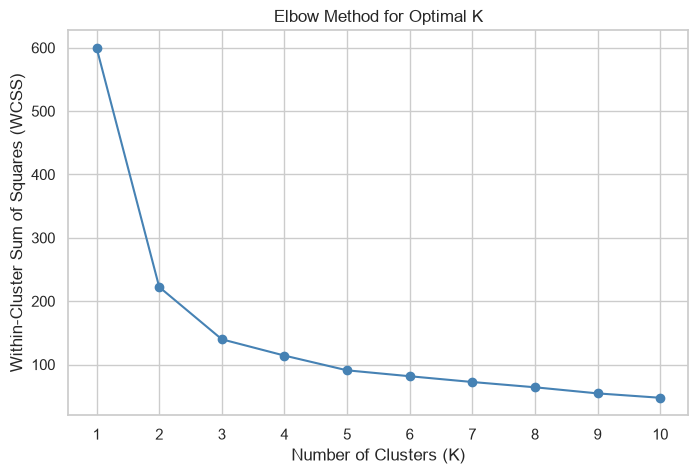

Observation: The 'elbow' point (where WCSS stops decreasing sharply) suggests the optimal K.


In [5]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', color="steelblue")
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(list(k_range))
plt.show()

print("Observation: The 'elbow' point (where WCSS stops decreasing sharply) suggests the optimal K.")


### Step 5: Silhouette Method - Finding Optimal K using Silhouette Score

In [6]:
silhouette_scores = []
k_range_sil       = range(2, 11)

for k in k_range_sil:
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    labels = kmeans.fit_predict(x_scaled)
    score  = silhouette_score(x_scaled, labels)
    silhouette_scores.append(score)

print("Silhouette scores for K = 2 to 10:")
for k, score in zip(k_range_sil, silhouette_scores):
    print(f"K={k}: Silhouette Score={score:.4f}")

Silhouette scores for K = 2 to 10:
K=2: Silhouette Score=0.5818
K=3: Silhouette Score=0.4599
K=4: Silhouette Score=0.3869
K=5: Silhouette Score=0.3459
K=6: Silhouette Score=0.3171
K=7: Silhouette Score=0.3202
K=8: Silhouette Score=0.3387
K=9: Silhouette Score=0.3424
K=10: Silhouette Score=0.3518


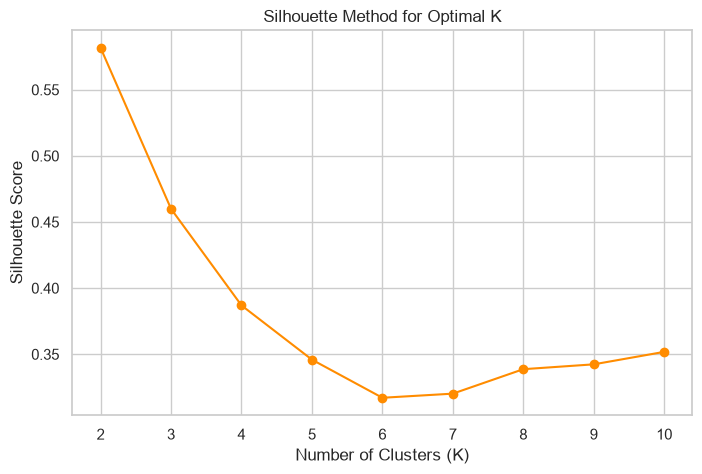

Optimal K based on highest Silhouette Score: 2


In [7]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range_sil), silhouette_scores, marker='o', color="darkorange")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method for Optimal K")
plt.xticks(list(k_range_sil))
plt.show()

best_k = list(k_range_sil)[np.argmax(silhouette_scores)]
print(f"Optimal K based on highest Silhouette Score: {best_k}")


### Step 6: Train Final K-Means Model with Optimal K

In [8]:
# Using the optimal K found from the Silhouette method
optimal_k = best_k

kmeans_final   = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
cluster_labels = kmeans_final.fit_predict(x_scaled)

# Adding cluster labels back to the original DataFrame for inspection
df["Cluster"] = cluster_labels
print(f"Final K-Means model trained with K = {optimal_k}")
df.head()

Final K-Means model trained with K = 2


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1


### Step 7: Visualize Clusters using PCA (2D Projection)

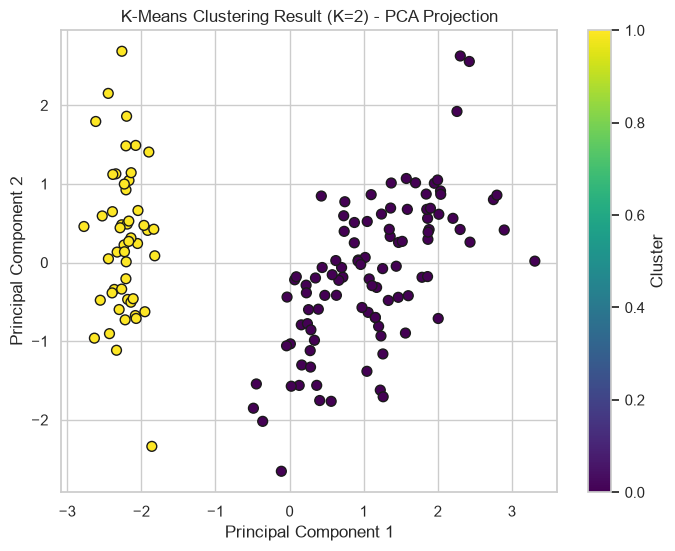

In [9]:
# Since we have 4 features, we reduce to 2D using PCA just for visualization purposes
pca   = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis", s=50, edgecolor="k")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title(f"K-Means Clustering Result (K={optimal_k}) - PCA Projection")
plt.colorbar(scatter, label="Cluster")
plt.show()


### Step 8: Compare Clusters with Actual Species Labels

In [10]:
# Since Iris actually has known labels, we can check how well clustering matched real species
comparison = pd.crosstab(df["Cluster"], iris.frame["target"].map(dict(enumerate(iris.target_names))))
print("Cluster vs Actual Species Comparison:\n")
print(comparison)

Cluster vs Actual Species Comparison:

target   setosa  versicolor  virginica
Cluster                               
0             0          50         50
1            50           0          0


### Step 9: Final Output

In [11]:
print("Experiment Completed Successfully")
print(f"\nOptimal number of clusters (K) selected : {optimal_k}")
print(f"Final Silhouette Score                    : {silhouette_score(x_scaled, cluster_labels):.4f}")


Experiment Completed Successfully

Optimal number of clusters (K) selected : 2
Final Silhouette Score                    : 0.5818
